In [4]:
!pip install torchmetrics optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 39.8 MB/s eta 0:00:00


In [1]:
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# from pathlib import Path

# img_path = Path(r'C:\Users\user\Desktop\div\others\test\shekil.png')
# img_tensor = torchvision.io.read_image(img_path)

# print(img_tensor.dtype, img_tensor.shape)

# plt.imshow(img_tensor.permute(1, 2, 0))
# plt.show()

In [3]:
from sklearn.datasets import load_sample_images

sample_images = load_sample_images()['images']
sample_images = np.stack(sample_images)
sample_images = torch.FloatTensor(sample_images)
sample_images /= 255

In [4]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)

print(sample_images_permuted.dtype, sample_images_permuted.shape)

torch.float32 torch.Size([2, 3, 427, 640])


In [5]:
def plot_image(img_tensor):
    plt.imshow(img_tensor.permute(1,2,0))
    plt.axis('off')

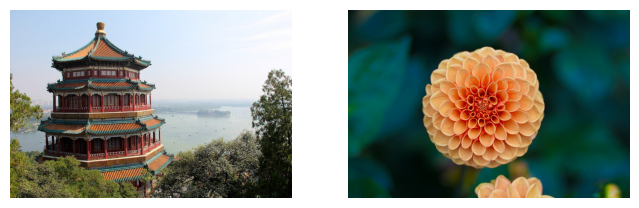

In [6]:
plt.figure(figsize=(8, 4))
for index, img_tensor in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(img_tensor)

In [7]:
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

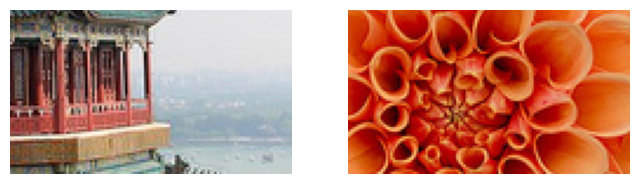

In [8]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plot_image(cropped_images[0])

plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [9]:
torch.manual_seed(42)

conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
print(cropped_images.shape)
print(conv_layer.weight.shape, conv_layer.padding,  conv_layer.stride)

fmaps = conv_layer(cropped_images)
print(fmaps.shape)

torch.Size([2, 3, 70, 120])
torch.Size([32, 3, 7, 7]) (0, 0) (1, 1)
torch.Size([2, 32, 64, 114])


# calculation of the output size

$$
\text{Output Height} = \frac{H_I - H_K + 2P}{S} + 1
$$

$$
\text{Output Width} = \frac{W_I - W_K + 2P}{S} + 1
$$

In [10]:
H_i, W_i = cropped_images.shape[-2:]
H_k, W_k = conv_layer.weight.shape[-2:]
P = conv_layer.padding[-2]
S = conv_layer.stride[-2]

H_o = (H_i - H_k + 2 * P) / S + 1
W_o = (W_i - W_k + 2 * P) / S + 1

H_o, W_o


(64.0, 114.0)

# calculation of the feature map

## 1st image, 1st fmap, 1st value

In [11]:
print(cropped_images[0, ...].shape)
window_3d = cropped_images[0, :, :7, :7]
print(window_3d.shape)

print(conv_layer.weight.shape)
kernel3d_weights = conv_layer.weight.data[0, ...]
kernel3d_biases = conv_layer.bias.data[0]
print(kernel3d_weights.shape, kernel3d_biases.shape)

torch.Size([3, 70, 120])
torch.Size([3, 7, 7])
torch.Size([32, 3, 7, 7])
torch.Size([3, 7, 7]) torch.Size([])


In [12]:
torch.sum(window_3d * kernel3d_weights) + kernel3d_biases

tensor(-0.1800)

In [13]:
fmaps[0, 0, ...]

tensor([[-0.1800, -0.0474, -0.0864,  ..., -0.5462, -0.5453, -0.5485],
        [-0.1327, -0.0746, -0.0779,  ..., -0.5462, -0.5477, -0.5488],
        [-0.1637, -0.0655, -0.1306,  ..., -0.5417, -0.5418, -0.5434],
        ...,
        [-0.0321, -0.0645, -0.0578,  ..., -0.5118, -0.4954, -0.4886],
        [-0.0207, -0.0016,  0.0225,  ..., -0.5112, -0.5027, -0.4986],
        [ 0.1434,  0.1303,  0.1060,  ..., -0.5101, -0.4955, -0.5002]],
       grad_fn=<SelectBackward0>)

## 1st image, all fmaps, 1st value

In [14]:
print(cropped_images[0, ...].shape)
window_3d = cropped_images[0:1, ..., :7, :7]
print(window_3d.shape)

print(conv_layer.weight.shape)
kernel3d_weights = conv_layer.weight.data
kernel3d_biases = conv_layer.bias.data
print(kernel3d_weights.shape, kernel3d_biases.shape)

torch.Size([3, 70, 120])
torch.Size([1, 3, 7, 7])
torch.Size([32, 3, 7, 7])
torch.Size([32, 3, 7, 7]) torch.Size([32])


In [15]:
fmaps_1st_value = (window_3d * kernel3d_weights).sum(dim=(1, 2, 3)) + kernel3d_biases

print(fmaps_1st_value.shape)
fmaps_1st_value

torch.Size([32])


tensor([-0.1800, -0.0895, -0.2501,  0.2870, -0.1033, -0.0494, -0.0716,  0.1195,
         0.0796,  0.0397,  0.0610, -0.0450,  0.0240, -0.1144,  0.2558, -0.1752,
         0.1470,  0.2807, -0.0709, -0.0365,  0.0283,  0.1976, -0.1139, -0.1695,
         0.0302, -0.1421,  0.0924,  0.2340, -0.1881,  0.0174, -0.6114, -0.0271])

In [16]:
fmaps[0, :, 0, 0]

tensor([-0.1800, -0.0895, -0.2501,  0.2870, -0.1033, -0.0494, -0.0716,  0.1195,
         0.0796,  0.0397,  0.0610, -0.0450,  0.0240, -0.1144,  0.2558, -0.1752,
         0.1470,  0.2807, -0.0709, -0.0365,  0.0283,  0.1976, -0.1139, -0.1695,
         0.0302, -0.1421,  0.0924,  0.2340, -0.1881,  0.0174, -0.6114, -0.0271],
       grad_fn=<SelectBackward0>)

## features

In [ ]:
# import torch.nn.functional as F

# F.conv2d(
#     cropped_images,
#     conv_layer.weight.data,
#     conv_layer.bias.data,
#     stride=1,
#     padding=0
# ).shape

torch.Size([2, 32, 64, 114])

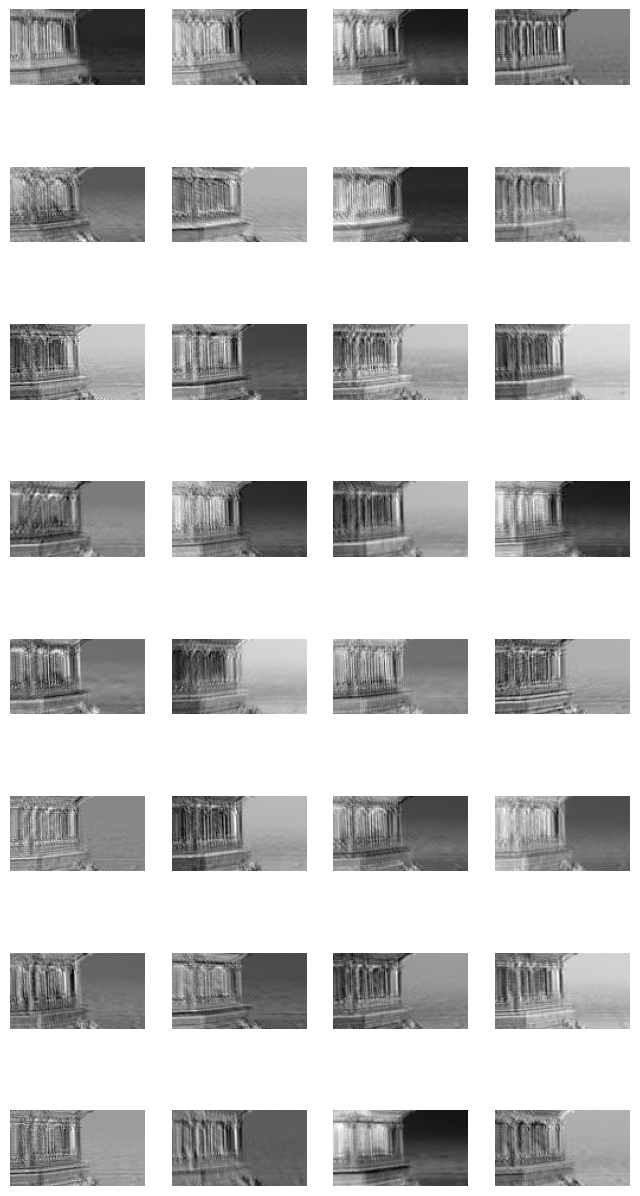

In [17]:
fig,axs = plt.subplots(8,4,figsize=(8,16))

for ind, ax in enumerate(axs.flat):
    ax.imshow(fmaps[0][ind].detach(), cmap='gray')
    ax.axis('off')

# pooling

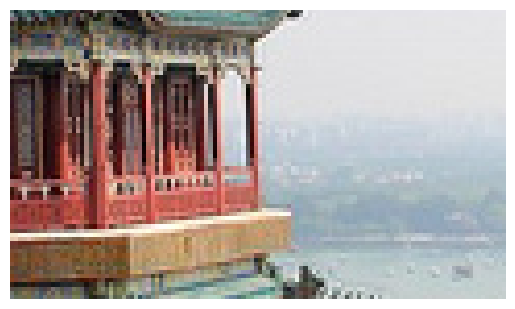

In [18]:
plot_image(cropped_images[0])

torch.Size([2, 3, 70, 120])
torch.Size([2, 3, 35, 60])


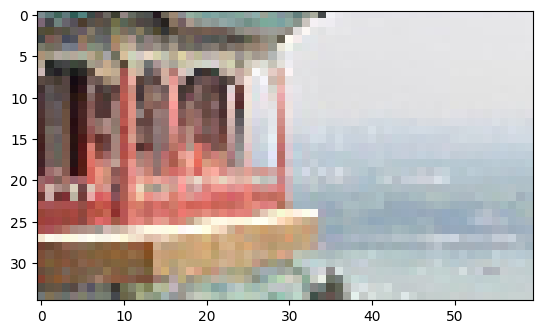

In [19]:
max_pool = nn.MaxPool2d(kernel_size=2)
output_max = max_pool(cropped_images)
print(cropped_images.shape)
print(output_max.shape)
plt.imshow(output_max[0].permute(1, 2, 0))

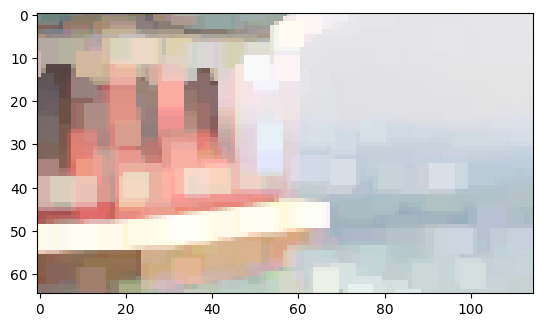

In [22]:
pooling_layer = nn.MaxPool2d(kernel_size=2, stride=1)

output = pooling_layer(cropped_images)
for i in range(4):
    output = pooling_layer(output)

plt.imshow(output[0].permute(1, 2, 0))

torch.Size([2, 3, 70, 120])
torch.Size([2, 3, 35, 60])


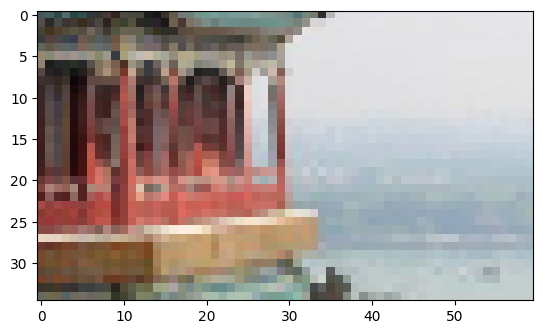

In [21]:
avg_pool = nn.AvgPool2d(kernel_size=2)
output_avg = avg_pool(cropped_images)
print(cropped_images.shape)
print(output_avg.shape)
plt.imshow(output_avg[0].permute(1, 2, 0))

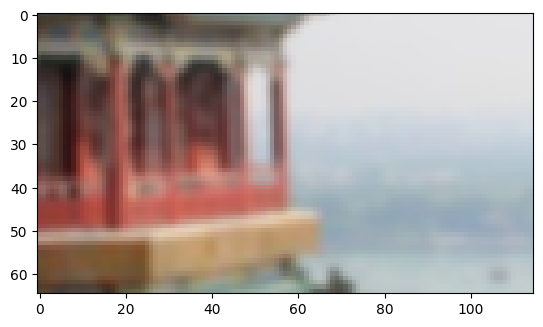

In [23]:
pooling_layer = nn.AvgPool2d(kernel_size=2, stride=1)

output = pooling_layer(cropped_images)
for i in range(4):
    output = pooling_layer(output)

plt.imshow(output[0].permute(1, 2, 0))

In [26]:
global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))
output = global_avg_pool(cropped_images)
output.shape

torch.Size([2, 3, 1, 1])

In [27]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)
output = global_avg_pool(cropped_images)
# output = cropped_images.mean(dim=(2, 3), keepdim=True)
output.shape

torch.Size([2, 3, 1, 1])

# train a classifier

In [ ]:
toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="data", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="data", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])
# train_data = torch.utils.data.Subset(train_and_valid_data, torch.randperm(len(train_and_valid_data))[:150])
# valid_data = torch.utils.data.Subset(train_and_valid_data, torch.randperm(len(train_and_valid_data))[:150])

from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 216kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.7MB/s]


In [29]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

# from functools import partial

# torch.manual_seed(42)  # extra code – ensure reproducibility
# DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")
# model = nn.Sequential(
#     DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2),
#     DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
#     DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2),
#     DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
#     DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2),
#     nn.Flatten(),
#     nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(in_features=128, out_features=64), nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(in_features=64, out_features=10),
# ).to(device)

model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, padding="same"), # [32, 64, 28, 28]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 64, 14, 14]
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 128, 7, 7]
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 256, 3, 3]
    nn.Flatten(), # [32, 2304]
    nn.Linear(in_features=2304, out_features=128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

In [31]:
from custom_utils import train, plot_history

n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(
	model,
	optimizer,
	criterion,
	metric,
	train_loader,
	valid_loader,
	n_epochs,
	warmup_scheduler=None,
	scheduler=None,
	patience=None,
	checkpoint_path='fashion_mnist_model.pt',
	clip_grad_norm=None,
  device=device
)

Epoch: 1/20, Train Loss: 0.76, Train Metric: 0.718, Valid Metric: 0.846, Time: 27.95s
	Checkpoint, valid metric: 0.846
Epoch: 2/20, Train Loss: 0.432, Train Metric: 0.851, Valid Metric: 0.881, Time: 20.6s
	Checkpoint, valid metric: 0.881
Epoch: 3/20, Train Loss: 0.376, Train Metric: 0.872, Valid Metric: 0.878, Time: 20.55s
Epoch: 4/20, Train Loss: 0.34, Train Metric: 0.884, Valid Metric: 0.901, Time: 21.63s
	Checkpoint, valid metric: 0.901
Epoch: 5/20, Train Loss: 0.314, Train Metric: 0.893, Valid Metric: 0.895, Time: 21.61s
Epoch: 6/20, Train Loss: 0.289, Train Metric: 0.902, Valid Metric: 0.902, Time: 20.6s
	Checkpoint, valid metric: 0.902
Epoch: 7/20, Train Loss: 0.274, Train Metric: 0.907, Valid Metric: 0.904, Time: 19.96s
	Checkpoint, valid metric: 0.904
Epoch: 8/20, Train Loss: 0.257, Train Metric: 0.911, Valid Metric: 0.911, Time: 20.75s
	Checkpoint, valid metric: 0.911
Epoch: 9/20, Train Loss: 0.242, Train Metric: 0.916, Valid Metric: 0.913, Time: 21.57s
	Checkpoint, valid metr

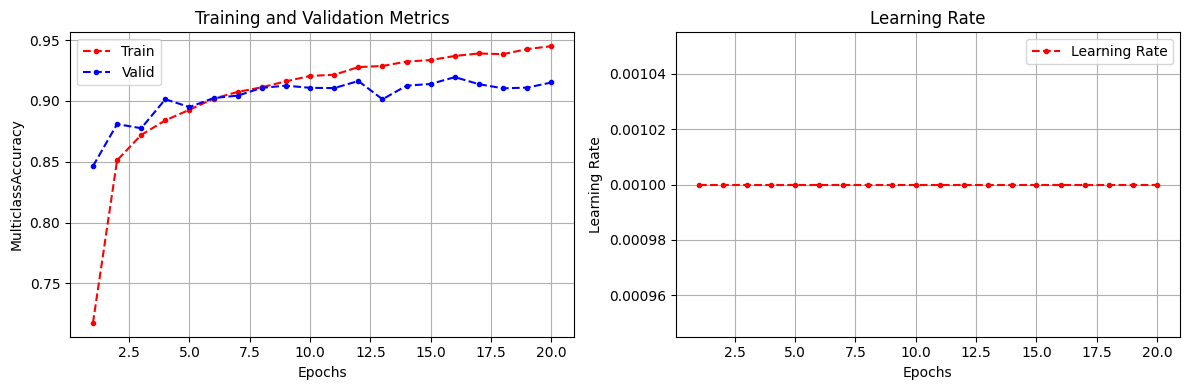

In [33]:
plot_history(history, metric)

# Using TorchVision's Pretrained Models

In [100]:
# !pip install beautifulsoup4 pandas lxml html5lib

In [101]:
import requests
import bs4
import pandas as pd

In [ ]:
url = r'https://docs.pytorch.org/vision/main/models.html'
res = requests.get(url)
soup = bs4.BeautifulSoup(res.content, 'html.parser')

# get table
section = soup.find('section', id='table-of-all-available-classification-weights')
table = section.find('table')

# get rows
rows = table.find_all('tr')

# 1st row is column names
headers = rows[0].find_all('th')
df_columns = [header.text.strip() for header in headers]

# 2+ rows are rows
df_rows = []
for row in rows[1:]:
    df_rows.append([td.text.strip() for td in row.find_all('td')])

df = pd.DataFrame(columns=df_columns, data=df_rows)
df

,model_weights,acc1,acc5,params,gflops,recipe
0,AlexNet_Weights.IMAGENET1K_V1,56.522,79.066,61.1M,0.71,link
1,ConvNeXt_Base_Weights.IMAGENET1K_V1,84.062,96.87,88.6M,15.36,link
2,ConvNeXt_Large_Weights.IMAGENET1K_V1,84.414,96.976,197.8M,34.36,link
3,ConvNeXt_Small_Weights.IMAGENET1K_V1,83.616,96.65,50.2M,8.68,link
4,ConvNeXt_Tiny_Weights.IMAGENET1K_V1,82.52,96.146,28.6M,4.46,link
...,...,...,...,...,...,...
110,ViT_L_32_Weights.IMAGENET1K_V1,76.972,93.07,306.5M,15.38,link
111,Wide_ResNet101_2_Weights.IMAGENET1K_V1,78.848,94.284,126.9M,22.75,link
112,Wide_ResNet101_2_Weights.IMAGENET1K_V2,82.51,96.02,126.9M,22.75,link
113,Wide_ResNet50_2_Weights.IMAGENET1K_V1,78.468,94.086,68.9M,11.4,link


In [ ]:
df.sort_values(by=['Acc@1', 'Acc@5'], ascending=False).head(20)

,model_weights,acc1,acc5,params,gflops,recipe
98,VGG16_Weights.IMAGENET1K_FEATURES,nan,nan,138.4M,15.47,link
105,ViT_H_14_Weights.IMAGENET1K_SWAG_E2E_V1,88.552,98.694,633.5M,1016.72,link
47,RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_E2E_V1,88.228,98.682,644.8M,374.57,link
108,ViT_L_16_Weights.IMAGENET1K_SWAG_E2E_V1,88.064,98.512,305.2M,361.99,link
57,RegNet_Y_32GF_Weights.IMAGENET1K_SWAG_E2E_V1,86.838,98.362,145.0M,94.83,link
48,RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_LINEAR_V1,86.068,97.844,644.8M,127.52,link
51,RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_E2E_V1,86.012,98.054,83.6M,46.73,link
18,EfficientNet_V2_L_Weights.IMAGENET1K_V1,85.808,97.788,118.5M,56.08,link
106,ViT_H_14_Weights.IMAGENET1K_SWAG_LINEAR_V1,85.708,97.73,632.0M,167.29,link
102,ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1,85.304,97.65,86.9M,55.48,link


In [104]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [105]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

In [106]:
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [ ]:
transform = weights.transforms()
preprocessed_images = transform(sample_images_permuted)
preprocessed_images.shape

torch.Size([2, 3, 224, 224])

In [ ]:
# sample_images_permuted.mean(dim=(2,3))
# transform(sample_images_permuted).mean(dim=(2,3))

In [ ]:
model.eval()
with torch.no_grad():
	y_logits = model(preprocessed_images.to(device))

y_probas = y_logits.softmax(dim=1)
y_probas

tensor([[0.0005, 0.0001, 0.0001,  ..., 0.0002, 0.0003, 0.0001],
        [0.0001, 0.0001, 0.0001,  ..., 0.0006, 0.0148, 0.0001]])

In [ ]:
y_pred = torch.argmax(y_probas, dim=1)
y_pred

tensor([698, 985])

In [112]:
class_names = weights.meta["categories"]
[class_names[class_id] for class_id in y_pred]

['palace', 'daisy']

In [ ]:
y_top3_probas, y_top3_class_ids = y_probas.topk(k=3, dim=1)
y_top3_probas, y_top3_class_ids

(tensor([[0.6504, 0.0894, 0.0149],
         [0.3803, 0.0452, 0.0436]]),
 tensor([[698, 663, 975],
         [985, 738, 310]]))

In [113]:
y_top3_logits, y_top3_class_ids = y_logits.topk(k=3, dim=1)
[[class_names[class_id] for class_id in top3] for top3 in y_top3_class_ids]

[['palace', 'monastery', 'lakeside'], ['daisy', 'pot', 'ant']]

# Transfer Learning

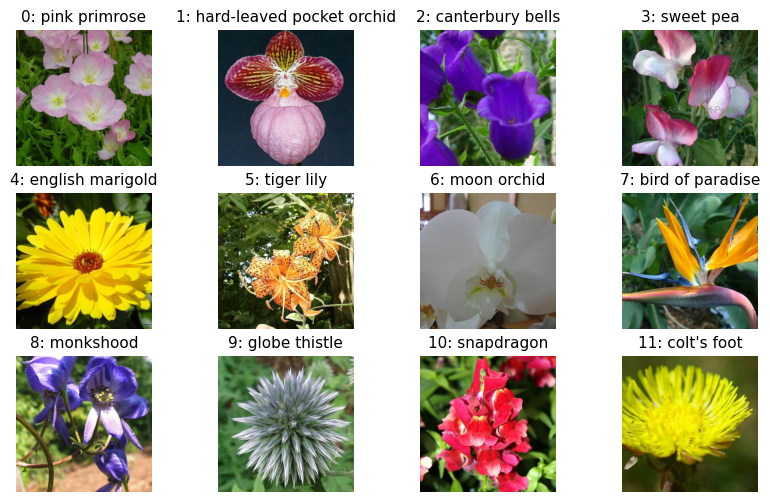

In [ ]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500),
])

flowers_to_display = torchvision.datasets.Flowers102(
	root="datasets",
	split="train",
	download=True,
	transform=transform,
)
sample_flowers = sorted({y: img for img, y in flowers_to_display}.items())[:12]
class_names = torchvision.datasets.Flowers102.classes

plt.figure(figsize=(10, 6))
for class_id, image in sample_flowers:
	if class_id == 12: 
		break
	plt.subplot(3, 4, class_id + 1)
	plot_image(image)
	plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

In [ ]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [ ]:
from torch.utils.data import DataLoader
from functools import partial

DefaultFlowers102 = partial(
    torchvision.datasets.Flowers102,
    root="datasets",
    transform=weights.transforms(),
    download=True
)

train_set = DefaultFlowers102(split="train")
valid_set = DefaultFlowers102(split="val")
test_set = DefaultFlowers102(split="test")

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [118]:
next(iter(test_loader))[0].shape

torch.Size([32, 3, 224, 224])

In [122]:
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=128, out_features=512, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=512, out_features=128, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(

In [123]:
[name for name, child in model.named_children()]

['features', 'avgpool', 'classifier']

In [124]:
len(model.features)

8

In [125]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [ ]:
n_classes = len(class_names)  # 102
model.classifier[2] = nn.Linear(1024, n_classes).to(device)

In [127]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
n_epochs = 5
optimizer = torch.optim.AdamW(model.parameters())
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=102).to(device)

history = train(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    device = device, 
    restore_best_parameters = False,
  )

Epoch: 1/5, Train Loss: 4.292, Train Metric: 0.15, Valid Metric: 0.575, Time: 31.45s
	Checkpoint, valid metric: 0.575
Epoch: 2/5, Train Loss: 2.993, Train Metric: 0.683, Valid Metric: 0.76, Time: 29.4s
	Checkpoint, valid metric: 0.760
Epoch: 3/5, Train Loss: 2.038, Train Metric: 0.852, Valid Metric: 0.824, Time: 29.32s
	Checkpoint, valid metric: 0.824
Epoch: 4/5, Train Loss: 1.374, Train Metric: 0.906, Valid Metric: 0.854, Time: 29.93s
	Checkpoint, valid metric: 0.854
Epoch: 5/5, Train Loss: 0.945, Train Metric: 0.941, Valid Metric: 0.878, Time: 28.98s
	Checkpoint, valid metric: 0.878
Restoring best model from epoch 5 with valid metric: 0.878


In [ ]:
history = train(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    device = device, 
    restore_best_parameters = False,
  )

Epoch: 1/5, Train Loss: 0.695, Train Metric: 0.959, Valid Metric: 0.875, Time: 29.27s
	Checkpoint, valid metric: 0.875
Epoch: 2/5, Train Loss: 0.517, Train Metric: 0.968, Valid Metric: 0.888, Time: 30.89s
	Checkpoint, valid metric: 0.888
Epoch: 3/5, Train Loss: 0.403, Train Metric: 0.976, Valid Metric: 0.888, Time: 28.43s
Epoch: 4/5, Train Loss: 0.307, Train Metric: 0.983, Valid Metric: 0.893, Time: 35.3s
	Checkpoint, valid metric: 0.893
Epoch: 5/5, Train Loss: 0.25, Train Metric: 0.991, Valid Metric: 0.891, Time: 28.66s
Restoring best model from epoch 4 with valid metric: 0.893


In [130]:
for param in model.parameters():
    param.requires_grad = True

In [ ]:
history = train(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    device = device,
  )

Epoch: 1/5, Train Loss: 0.734, Train Metric: 0.799, Valid Metric: 0.814, Time: 60.64s
	Checkpoint, valid metric: 0.814
Epoch: 2/5, Train Loss: 0.196, Train Metric: 0.943, Valid Metric: 0.847, Time: 54.95s
	Checkpoint, valid metric: 0.847
Epoch: 3/5, Train Loss: 0.101, Train Metric: 0.975, Valid Metric: 0.861, Time: 58.59s
	Checkpoint, valid metric: 0.861
Epoch: 4/5, Train Loss: 0.087, Train Metric: 0.98, Valid Metric: 0.855, Time: 53.71s
Epoch: 5/5, Train Loss: 0.106, Train Metric: 0.974, Valid Metric: 0.875, Time: 59.1s
	Checkpoint, valid metric: 0.875
Restoring best model from epoch 5 with valid metric: 0.875


In [ ]:
model.eval()
metric.reset()
with torch.no_grad():
# with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred_logits = model(X_batch)
		y_pred = y_pred_logits.argmax(dim=1)
		metric.update(y_pred_logits, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

In [ ]:
model.eval()

X_new, y_new = next(iter(test_loader))
X_new, y_new = X_new.to(device), y_new.to(device)

with torch.inference_mode():
    y_pred_logits = model(X_new)
    y_pred = y_pred_logits.argmax(dim=1)
    y_proba = y_pred_logits.softmax(dim=1).round(decimals=3)

[test_data.classes[c] for c in y_pred]

In [ ]:
# import torch.nn.functional as F
# y_proba = F.softmax(y_pred_logits, dim=1).round(decimals=3)

In [132]:
import torchvision.transforms.v2 as T

transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=30),
    T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# Classification and Localization

In [ ]:
class FlowerLocator(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.localization_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_model.classifier[2].in_features, 4)
        )

    def forward(self, X):
        features = self.base_model.features(X)
        pool = self.base_model.avgpool(features)
        y_pred_logits = self.base_model.classifier(pool)
        y_pred_bbox = self.localization_head(pool)
        return y_pred_logits, y_pred_bbox

torch.manual_seed(42)
locator_model = FlowerLocator(model).to(device)

In [ ]:
preproc_images = torch.randn(2, 3, 224, 224)  # a batch of preprocessed images
y_pred_logits, y_pred_bbox = locator_model(preprocessed_images.to(device))

In [ ]:
import torchvision.tv_tensors

bbox = torchvision.tv_tensors.BoundingBoxes(
    [[377, 199, 248, 262]],  # center x=377, center y=199, width=248, height=262
    format="CXCYWH",  # other possible formats: "XYXY" and "XYWH"
    canvas_size=(500, 754)  # raw image size before preprocessing
)